Benchmark between using List and Set
---

In [1]:
import OPPs
import OrbitRepresentatives as ORs
import numpy as np
import timeit
from IPython import get_ipython
import pickle

In [2]:
# Define N and initialise runtime lists
logspace_values = np.logspace(0, 2, num=10)
int_values = np.round(logspace_values).astype(int)
np.random.shuffle(int_values)
N = int_values
print(N)
runtime_list = []
runtime_set = []

[  1  36   8   2   3  22 100  13  60   5]


List
---

In [3]:
for n in N:
    alist = [[0] for x in range(n)]
    alist[0] = [i for i in range(1, n)]
    Gstar = OPPs.Graph(alist)
    pi = [[0], [i for i in range(1, n)]]
    
    # Measure time
    t = timeit.timeit(lambda: ORs.OrbitRepresentatives(Gstar, pi, False), number=1)
    runtime_list.append(t)
    print(f'N={n}, List runtime: {t:.5f}s')
    

N=1, List runtime: 0.00001s
N=36, List runtime: 17581.98805s
N=8, List runtime: 0.02320s
N=2, List runtime: 0.00003s
N=3, List runtime: 0.00006s
N=22, List runtime: 4.35099s
N=100, List runtime: 45574.61531s
N=13, List runtime: 0.20567s
N=60, List runtime: 668.11145s
N=5, List runtime: 0.00264s


In [4]:
# Save variables
with open('benchmark_data.pkl', 'wb') as f:
    
    pickle.dump((N, runtime_list, runtime_set), f)

In [5]:
# Reset the kernel
ipython = get_ipython()
ipython.run_line_magic('reset', '-f')

# Reload variables
import pickle
with open('benchmark_data.pkl', 'rb') as f:

    N, runtime_list, runtime_set = pickle.load(f)
    

Set
---

In [6]:
# Re-import modules after reset
import OPPs_set
import OrbitRepresentatives_set as ORs_set
import timeit
import numpy as np

In [7]:
for n in N:
    alist_set = [[0] for x in range(n)]
    alist_set[0] = [i for i in range(1, n)]
    Gstar_set = OPPs_set.Graph(alist_set)
    pi = [[0], [i for i in range(1, n)]]
    
    # Measure time
    t = timeit.timeit(lambda: ORs_set.OrbitRepresentatives(Gstar_set, pi, False), number=1)
    runtime_set.append(t)
    print(f'N={n}, Set runtime: {t:.5f}s')

N=1, Set runtime: 0.00002s
N=36, Set runtime: 56.75309s
N=8, Set runtime: 0.01994s
N=2, Set runtime: 0.00006s
N=3, Set runtime: 0.00008s
N=22, Set runtime: 5.63711s
N=100, Set runtime: 7299.84127s
N=13, Set runtime: 0.17396s
N=60, Set runtime: 413.99481s
N=5, Set runtime: 0.00092s


Plotting Results
---

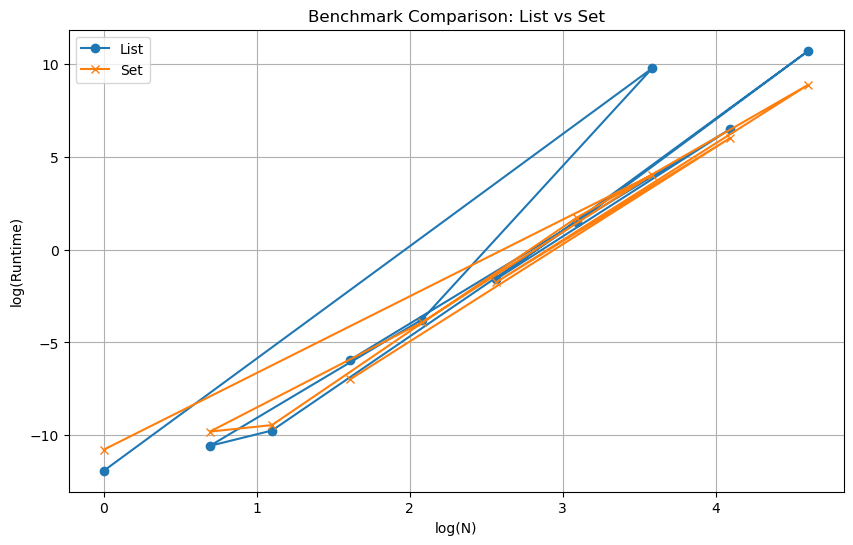

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(np.log(N), np.log(runtime_list), label='List', marker='o')
plt.plot(np.log(N), np.log(runtime_set), label='Set', marker='x')
plt.xlabel('log(N)')
plt.ylabel('log(Runtime)')
plt.title('Benchmark Comparison: List vs Set')
plt.legend()
plt.grid(True)
plt.show()
    